In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = M**(-3) * Lambda

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 100

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-1.34058809e-02, -7.60388889e-03, -4.11326925e-03, -2.01322749e-03,
       -7.49791237e-04,  1.03227754e-05,  4.67625872e-04,  7.42750549e-04,
        9.08272253e-04,  1.00785414e-03,  1.06776503e-03,  1.10380888e-03,
        1.12549373e-03,  1.13853987e-03,  1.14638875e-03,  1.15111082e-03,
        1.15395173e-03,  1.15566090e-03,  1.15668917e-03,  1.15730781e-03,
        1.15767999e-03,  1.15790391e-03,  1.15803862e-03,  1.15811967e-03,
        1.15816843e-03,  1.15819776e-03,  1.15819957e-03,  1.15820138e-03,
        1.15820319e-03,  1.15820500e-03,  1.15820681e-03,  1.15820861e-03,
        1.15821042e-03,  1.15821223e-03,  1.15821404e-03,  1.15821585e-03,
        1.15821765e-03,  1.15821946e-03,  1.15822127e-03,  1.15822308e-03,
        1.15822489e-03,  1.15822670e-03,  1.15822850e-03,  1.15823031e-03,
        1.15823212e-03,  1.15823393e-03,  1.15823574e-03,  1.15823755e-03,
        1.15823935e-03,  1.15824116e-03,  1.15824297e-03,  1.15824478e-03,
        1.15824659e-03,  

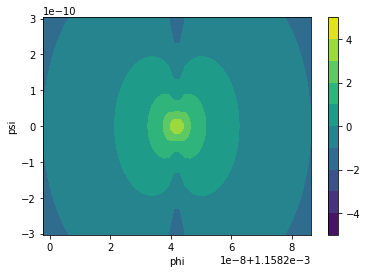

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

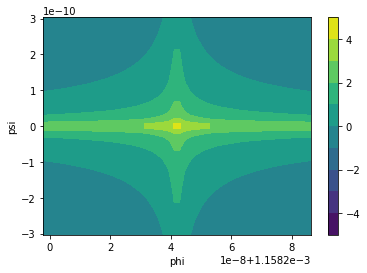

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [10]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [11]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

[[8.620762656104622e+20 -1.917565035646656e-03 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-3.214737867137442e-03 7.917181960577353e+20 -4.162389905849015e-03 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.389400262679657e-03 7.497498777030157e+20 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  2.308676954363506e+20 -8.389987838120087e-03 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -6.479830590690470e-03 2.637345547084524e+20 -5.004567007995013e-03]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -3.865169345103280e-03 3.188343821734315e+20]]


<ipython-input-12-e4c02b133dbc>:2: RuntimeWarning: divide by zero encountered in log10
  cntr1 = ax1.contourf(np.arange((nGrid-2)**2), np.arange((nGrid-2)**2), np.log10(np.abs(fpFinDiff_NeuDir)))


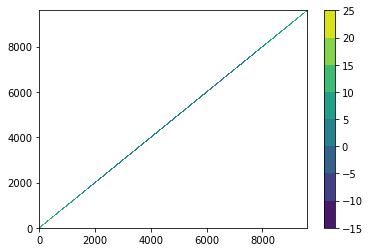

In [12]:
fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(np.arange((nGrid-2)**2), np.arange((nGrid-2)**2), np.log10(np.abs(fpFinDiff_NeuDir)))
fig.colorbar(cntr1, ax=ax1)
plt.show()

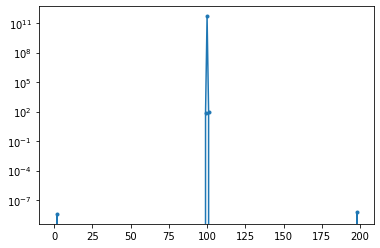

In [13]:
ax = plt.gca()
plt.plot(np.abs(fpFinDiff_NeuDir[1000,900:1100]), marker=".")
ax.set_yscale("log")
plt.show()

In [14]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [15]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

[[8.620762656104622e+20 -1.917565035646656e-03 0.000000000000000e+00 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [-3.214737867137442e-03 7.917181960577353e+20 -4.162389905849015e-03 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 [0.000000000000000e+00 -5.389400262679657e-03 7.497498777030157e+20 ...
  0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00]
 ...
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  2.308676954363506e+20 -8.389987838120087e-03 0.000000000000000e+00]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  -6.479830590690470e-03 2.637345547084524e+20 -5.004567007995013e-03]
 [0.000000000000000e+00 0.000000000000000e+00 0.000000000000000e+00 ...
  0.000000000000000e+00 -3.865169345103280e-03 3.188343821734315e+20]]


c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


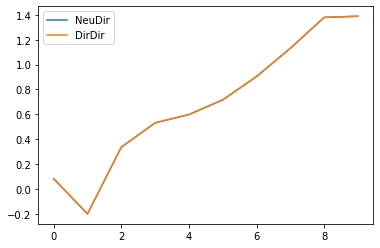

In [16]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [17]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[ 0.08159241+0.j -0.20199843+0.j  0.33511759+0.j  0.53116837+0.j
  0.59772361+0.j  0.71614297+0.j  0.90412394+0.j  1.13176207+0.j
  1.37988417+0.j  1.38916482+0.j]
[ 0.08159241+0.j -0.20199843+0.j  0.33511759+0.j  0.53116837+0.j
  0.59772361+0.j  0.71614297+0.j  0.90412394+0.j  1.13176207+0.j
  1.37988417+0.j  1.38916482+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


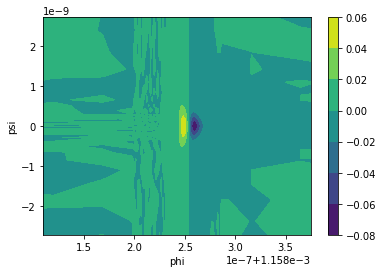

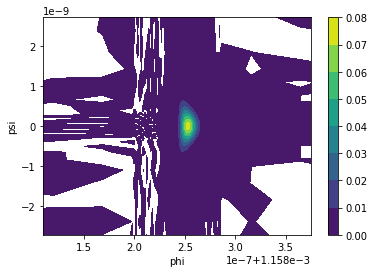

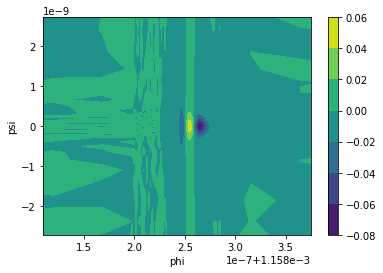

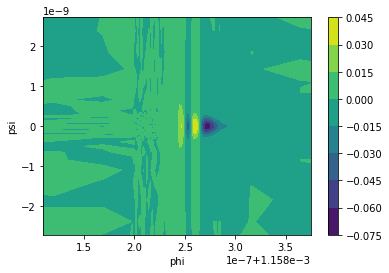

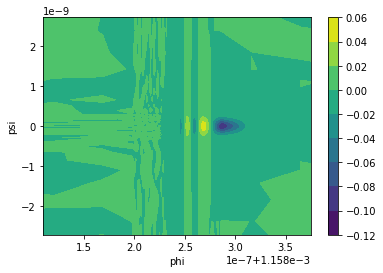

In [18]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

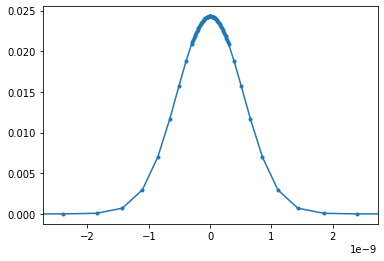

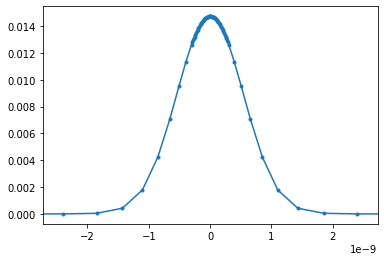

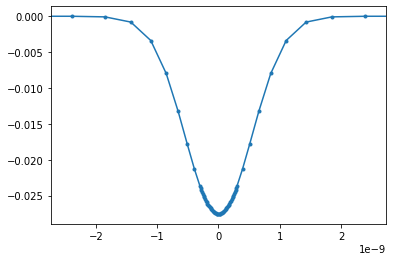

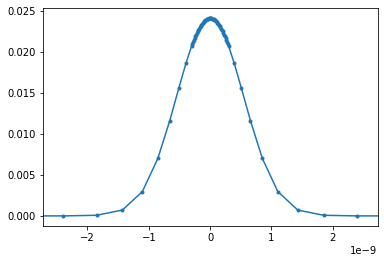

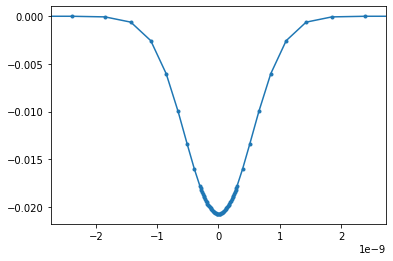

In [19]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

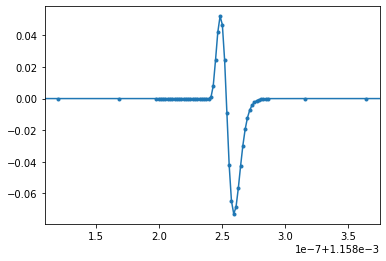

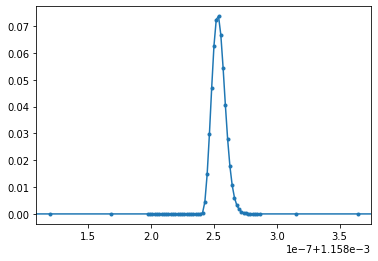

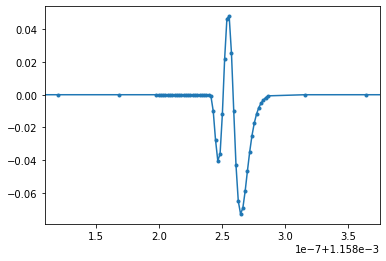

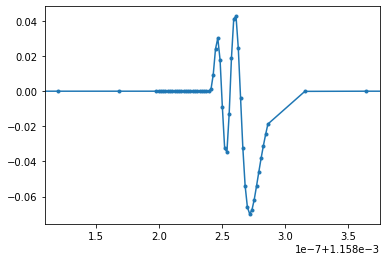

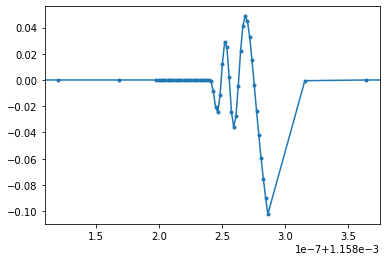

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()

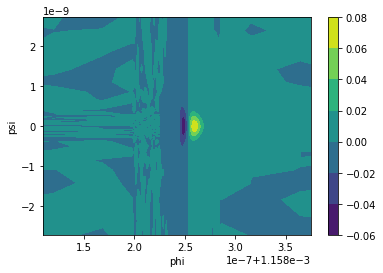

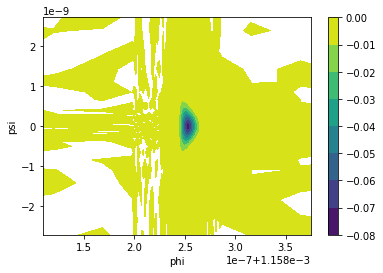

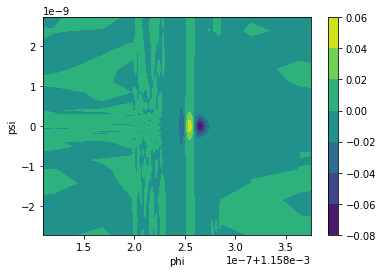

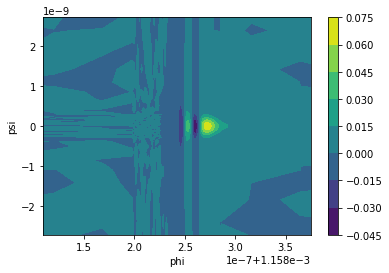

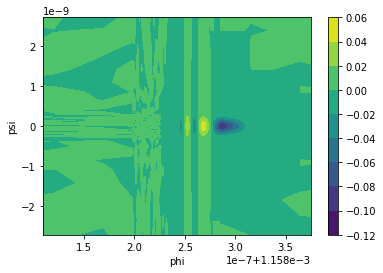

In [21]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

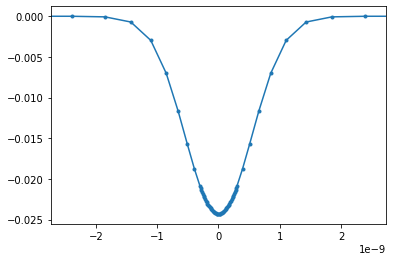

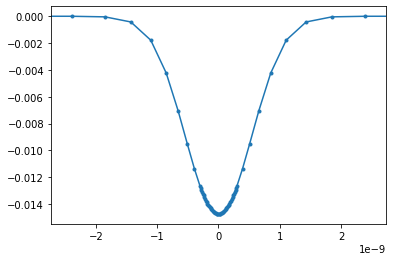

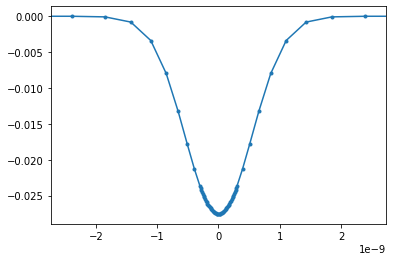

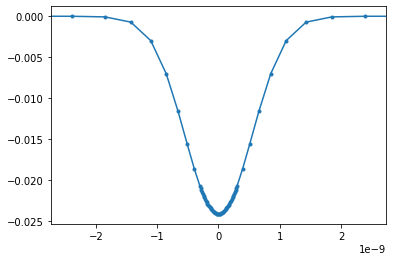

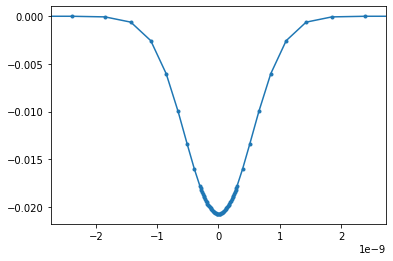

In [22]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

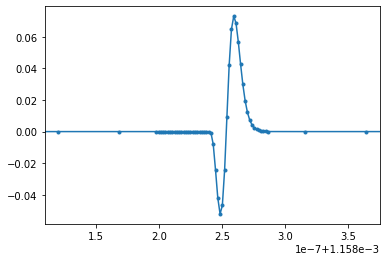

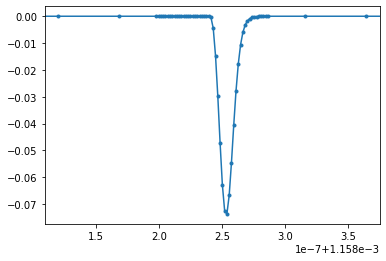

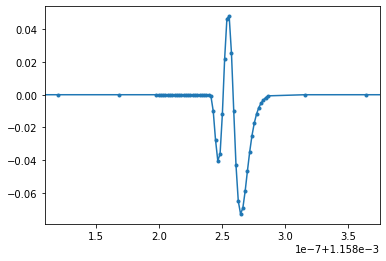

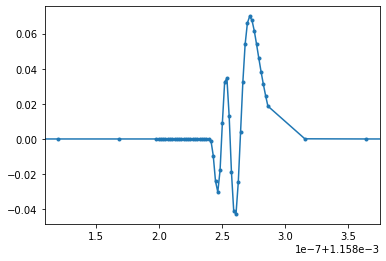

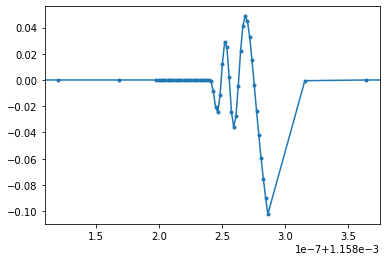

In [23]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()

In [24]:
# 局在した場所でスライスして1次元の問題として解く
infPotFunc_phiLoc = lambda psi: infPotFunc([phic, psi])
infPotDerivFunc_psi_phiLoc = lambda psi: infPotDerivFunc_psi([phic, psi])
infPotDeriv2Func_psi_phiLoc = lambda psi: infPotDeriv2Func_psi([phic, psi])

In [25]:
customGrid_psi_fine = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), 1001))[:-1],
                                      np.linspace(psiLargeEtaMin, psiLargeEtaMax, 2000),
                                      np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), 1001))[1:]])

fpFinDiff_phiLoc = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLoc,
    [infPotDerivFunc_psi_phiLoc],
    [infPotDeriv2Func_psi_phiLoc],
    [nGrid],
    [psimax],
    [psimin],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid_psi_fine],
    set0OutOfInfRegion=False
)

eigVals_phiLoc, eigVecs_phiLoc = np.linalg.eig(fpFinDiff_phiLoc)
eigVecsSort_phiLoc = eigVecs_phiLoc.T[np.argsort(eigVals_phiLoc)]
eigValsSort_phiLoc = np.sort(eigVals_phiLoc)

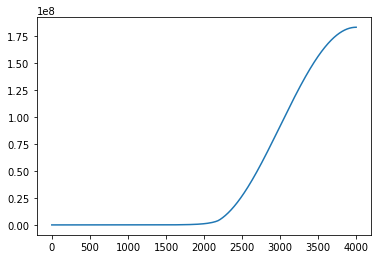

In [26]:
ax = plt.gca()
plt.plot(eigValsSort_phiLoc)
plt.show()

In [27]:
eigValsSort_phiLoc[:20]

array([-8.19565161e-08,  8.38418328e-03,  2.72842625e-02,  5.05999598e-02,
        7.81566447e-02,  1.09395216e-01,  1.43922188e-01,  1.81450760e-01,
        2.21757452e-01,  2.64661948e-01,  3.10015014e-01,  3.57690512e-01,
        4.07579156e-01,  4.59585413e-01,  5.13625454e-01,  5.69624756e-01,
        6.27515242e-01,  6.87235568e-01,  7.48730305e-01,  8.11948121e-01])

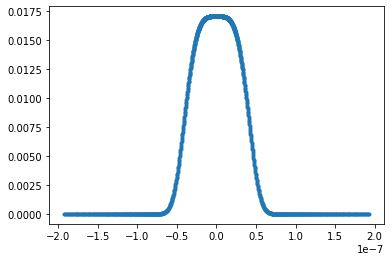

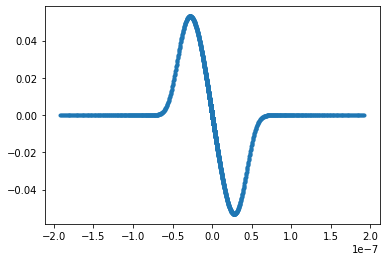

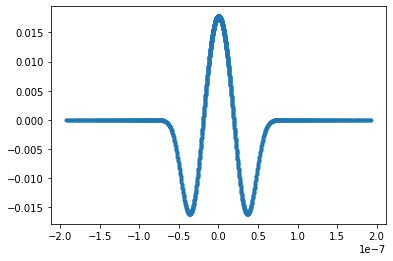

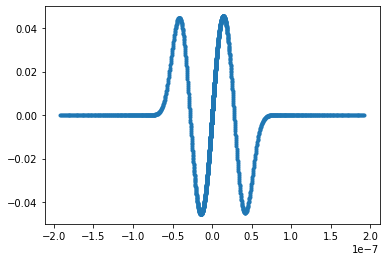

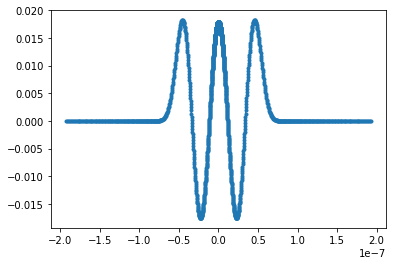

In [28]:
ax = plt.gca()

for iEig in range(5):
    plt.plot(customGrid_psi_fine[1:-1], eigVecsSort_phiLoc[iEig], marker='.')
    plt.show()

In [29]:
iMid = (nGrid - 2) * ((nGrid - 2) // 2)

In [30]:
phiMid = customGrid_phi_woEnd[iMid//(nGrid - 2)]

In [31]:
fpFinDiff_DirDir[(iMid-1):(iMid+5),(iMid-1):(iMid+5)]

array([[ 7.85245884e+08,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  7.85258132e+08, -2.45136768e-03,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -4.10964032e-03,  2.79424613e+08,
        -5.32110089e-03,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00, -6.88968194e-03,
         9.94365201e+07, -8.92065724e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.15503337e-02,  3.53896153e+07, -1.49551995e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.93637689e-02,  1.25975847e+07]])

In [32]:
fpFinDiff_phiLoc_part = fpFinDiff_DirDir[iMid:(iMid+nGrid-2),iMid:(iMid+nGrid-2)]

eigVals_phiLoc_part, eigVecs_phiLoc_part = np.linalg.eig(fpFinDiff_phiLoc_part)
eigVecsSort_phiLoc_part = eigVecs_phiLoc_part.T[np.argsort(eigVals_phiLoc_part)]
eigValsSort_phiLoc_part = np.sort(eigVals_phiLoc_part)

In [33]:
eigValsSort_phiLoc_part[:20]

array([  3.23258887,  14.83032227,  27.96753965,  41.98537281,
        56.31028658,  70.46562068,  85.18039324, 100.59270391,
       106.87224715, 111.74837777, 132.98809136, 167.00703367,
       206.58846967, 206.58857956, 214.79142558, 274.82223637,
       357.11884201, 462.73905142, 497.81115672, 497.81115672])

In [34]:
# 局在した場所でスライスして1次元の問題として解く
infPotFunc_phiLocMid = lambda psi: infPotFunc([phiMid, psi])
infPotDerivFunc_psi_phiLocMid = lambda psi: infPotDerivFunc_psi([phiMid, psi])
infPotDeriv2Func_psi_phiLocMid = lambda psi: infPotDeriv2Func_psi([phiMid, psi])

fpFinDiff_phiLocMid = InfAdjFPFiniteDiff(
    1,
    infPotFunc_phiLocMid,
    [infPotDerivFunc_psi_phiLocMid],
    [infPotDeriv2Func_psi_phiLocMid],
    [nGrid],
    [psimax],
    [psimin],
    ["Dirichlet"],
    ["Dirichlet"],
    customGrid=[customGrid_psi_fine],
    set0OutOfInfRegion=False
)

eigVals_phiLocMid, eigVecs_phiLocMid = np.linalg.eig(fpFinDiff_phiLocMid)
eigVecsSort_phiLocMid = eigVecs_phiLocMid.T[np.argsort(eigVals_phiLocMid)]
eigValsSort_phiLocMid = np.sort(eigVals_phiLocMid)

In [35]:
eigValsSort_phiLocMid[:20]

array([-3.17102493e-05,  9.30980850e+00,  1.86195956e+01,  2.79292907e+01,
        3.72388356e+01,  4.65481880e+01,  5.58573015e+01,  6.51661117e+01,
        7.44746046e+01,  8.37826736e+01,  9.30903558e+01,  1.02397485e+02,
        1.11704166e+02,  1.21010159e+02,  1.30315645e+02,  1.39620307e+02,
        1.48924403e+02,  1.58227539e+02,  1.67530050e+02,  1.76831468e+02])